# Amazon Polarity Quick Analysis

This notebook loads the 10k training subset, previews samples, prints quick stats, and creates simple visualizations.

In [1]:
from pathlib import Path
import re
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('default')

In [2]:
def print_samples(df: pd.DataFrame, sample_n: int = 5) -> None:
    print('=' * 80)
    print('Dataset preview (first rows)')
    print('=' * 80)
    print(df.head(sample_n).to_string(index=False, max_colwidth=80))

    print('\n' + '=' * 80)
    print('Random samples')
    print('=' * 80)
    random_rows = df.sample(n=sample_n, random_state=42)
    for i, row in enumerate(random_rows.itertuples(index=False), 1):
        content_preview = str(row.content).replace('\n', ' ')[:180]
        print(f'[{i}] label={row.label} | title={str(row.title)[:80]}')
        print(f'    content={content_preview}...')


def plot_label_distribution(df: pd.DataFrame, output_path: Path) -> None:
    label_names = {0: 'Negative', 1: 'Positive'}
    counts = df['label'].value_counts().sort_index()
    labels = [label_names.get(x, str(x)) for x in counts.index]

    plt.figure(figsize=(8, 5))
    bars = plt.bar(labels, counts.values)
    plt.title('Amazon Polarity Label Distribution (train_10k)')
    plt.xlabel('Label')
    plt.ylabel('Count')

    for bar, val in zip(bars, counts.values):
        plt.text(bar.get_x() + bar.get_width() / 2, val, str(val), ha='center', va='bottom')

    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.show()


def plot_content_length(df: pd.DataFrame, output_path: Path) -> None:
    lengths = df['content'].fillna('').str.len()

    plt.figure(figsize=(8, 5))
    plt.hist(lengths, bins=40)
    plt.title('Content Length Distribution (Characters)')
    plt.xlabel('Characters')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.show()


def print_top_words(df: pd.DataFrame, top_k: int = 12) -> None:
    stopwords = {
        'the', 'a', 'an', 'and', 'or', 'is', 'are', 'to', 'of', 'in', 'for', 'it', 'this',
        'that', 'on', 'with', 'as', 'was', 'were', 'be', 'have', 'has', 'had', 'i', 'you',
        'my', 'we', 'they', 'he', 'she', 'at', 'from', 'but', 'not', 'so', 'if', 'very',
    }

    def tokenize(text: str):
        return [w for w in re.findall(r"[a-zA-Z']+", text.lower()) if w not in stopwords and len(w) > 2]

    print('\n' + '=' * 80)
    print('Top words by label (quick lexical signal check)')
    print('=' * 80)

    for label in sorted(df['label'].unique()):
        text = ' '.join(df.loc[df['label'] == label, 'content'].fillna('').astype(str).tolist())
        freq = Counter(tokenize(text)).most_common(top_k)
        pretty = ', '.join([f'{w}:{c}' for w, c in freq])
        label_name = 'Positive' if label == 1 else 'Negative'
        print(f'label={label} ({label_name}): {pretty}')

In [3]:
base_dir = Path.cwd()
train_path = base_dir / 'amazon_polarity_small' / 'train_10k.csv'
out_dir = base_dir / 'analysis_outputs'
out_dir.mkdir(parents=True, exist_ok=True)

if not train_path.exists():
    raise FileNotFoundError(f'Could not find dataset file: {train_path}')

df = pd.read_csv(train_path)
print(f'Loaded: {train_path}')
print(f'Rows: {len(df)}')
print(f'Columns: {list(df.columns)}')

Loaded: d:\code\hk\584 nlp hk\project\dataset\amazon_polarity_small\train_10k.csv
Rows: 10000
Columns: ['label', 'title', 'content']


In [4]:
print_samples(df, sample_n=5)

Dataset preview (first rows)
 label                                                      title                                                                          content
     0 Anyone who likes this better than the Pekinpah is a moron. All the pretty people in this film. Even the Rudy character played by Michael...
     0                             Author seems mentally unstable I know that Tom Robbins has a loyal following and I started the book with hig...
     1                                           Spaetzle Noodles This type of spaetzle maker is easier to manuveur than the old press kind and...
     1                Cool product until the cats lost it . . . . My cats seemed to be amused to work for their food. One cat would roll the ba...
     1                                          Works as expected I've had no problems running this with my Dell 8200 PC running Windows XP Hom...

Random samples
[1] label=0 | title=no good
    content=ok it is very breakable (that is 

In [5]:
print('=' * 80)
print('Basic stats')
print('=' * 80)
print(df['label'].value_counts().sort_index().to_string())
print('Average content length:', round(df['content'].fillna('').str.len().mean(), 2))

Basic stats
label
0    5003
1    4997
Average content length: 403.41


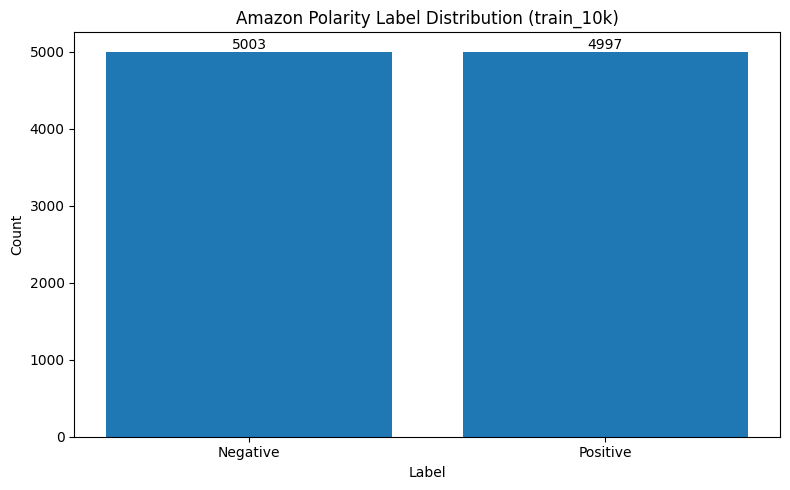

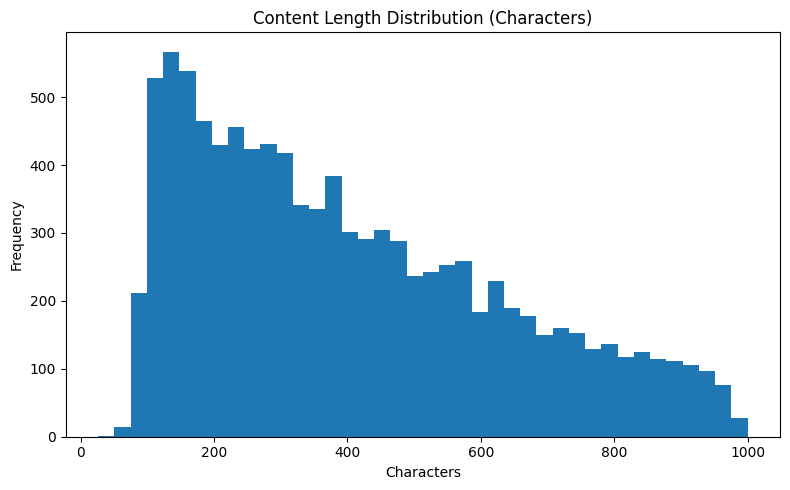

Saved plots:
- d:\code\hk\584 nlp hk\project\dataset\analysis_outputs\label_distribution.png
- d:\code\hk\584 nlp hk\project\dataset\analysis_outputs\content_length_distribution.png


In [6]:
label_plot = out_dir / 'label_distribution.png'
length_plot = out_dir / 'content_length_distribution.png'

plot_label_distribution(df, label_plot)
plot_content_length(df, length_plot)

print('Saved plots:')
print(f'- {label_plot}')
print(f'- {length_plot}')

In [7]:
print_top_words(df, top_k=12)


Top words by label (quick lexical signal check)
label=0 (Negative): book:2343, one:1869, all:1535, like:1484, would:1469, just:1392, out:1273, about:1173, what:1054, good:1043, when:1040, get:1037
label=1 (Positive): book:2527, one:1714, great:1671, all:1488, like:1301, good:1298, just:1091, read:1017, about:1003, will:991, out:980, it's:970
